# ControlGen Visualization

This notebook generates or loads a ControlGen sample and visualizes the input/output trajectory,
response metrics, and pole-zero map.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import numpy as np


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate repo root from notebook path")


ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/controlgen-mpl")

import matplotlib.pyplot as plt

from controlgen.generator import DatasetConfig, generate_sample

plt.style.use("seaborn-v0_8-whitegrid")
ROOT

Matplotlib is building the font cache; this may take a moment.


PosixPath('/home/fan/AP/ControlGen')

In [2]:
def load_jsonl_sample(path: Path, index: int = 0) -> dict:
    with path.open("r", encoding="utf-8") as handle:
        for line_no, line in enumerate(handle):
            if line_no == index:
                return json.loads(line)
    raise IndexError(f"Sample index {index} out of range for {path}")


def summarize_sample(sample: dict) -> None:
    print("sample_id:", sample["sample_id"])
    print("dsl_text:", sample["dsl_text"])
    print("input_spec:", sample["input_spec"])
    print("tags:", sample["tags"])
    print("metrics:")
    for key, value in sample["metrics"].items():
        if key in {"poles", "zeros"}:
            continue
        print(f"  {key}: {value}")


def plot_sample(sample: dict) -> None:
    t = np.asarray(sample["t"], dtype=float)
    u = np.asarray(sample["u"], dtype=float)
    y = np.asarray(sample["y"], dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    axes[0].plot(t, u, label="u(t)", linewidth=2)
    axes[0].plot(t, y, label="y(t)", linewidth=2)
    axes[0].set_title("Input / Output Response")
    axes[0].set_xlabel("Time [s]")
    axes[0].legend()

    poles = sample["metrics"].get("poles", [])
    zeros = sample["metrics"].get("zeros", [])
    if poles:
        axes[1].scatter(
            [pole["real"] for pole in poles],
            [pole["imag"] for pole in poles],
            marker="x",
            s=80,
            label="Poles",
        )
    if zeros:
        axes[1].scatter(
            [zero["real"] for zero in zeros],
            [zero["imag"] for zero in zeros],
            marker="o",
            s=60,
            facecolors="none",
            label="Zeros",
        )
    axes[1].axhline(0.0, color="black", linewidth=1)
    axes[1].axvline(0.0, color="black", linewidth=1)
    axes[1].set_title("Pole / Zero Map")
    axes[1].set_xlabel("Real")
    axes[1].set_ylabel("Imag")
    axes[1].legend()

    fig.suptitle(sample["sample_id"])
    fig.tight_layout()
    plt.show()


## Generate a fresh sample

Use the generator directly when you want to inspect a newly sampled control system.

sample_id: bfe6931b6138
dsl_text: feedback(forward=series(pid(kp=3.4626721, ki=1.39473606, kd=0.05650641, tau=0.05, name='controller'), tf(num=[2.42237362, 3.55088795], den=[1, 1.95062131], name='compensator'), tf(num=[2.80226547], den=[1, 2.28872311, 1.30118634], name='plant')), feedback=gain(k=2.03843582, name='sensor'), sign=-1)
input_spec: {'kind': 'step', 'amplitude': 1.734142419906245, 'frequency': 0.499072778944598, 'phase': 0.0}
tags: {'closed_loop': True, 'controller_type': 'pid', 'order': 5, 'stable': True, 'pole_count': 5, 'zero_count': 3, 'difficulty': 'level2'}
metrics:
  stable: True
  final_value: 0.8504565757235905
  steady_state_error: 0.8836858441826545
  overshoot: 0.0
  peak: 1.2623855467582918
  settling_time: 1.95


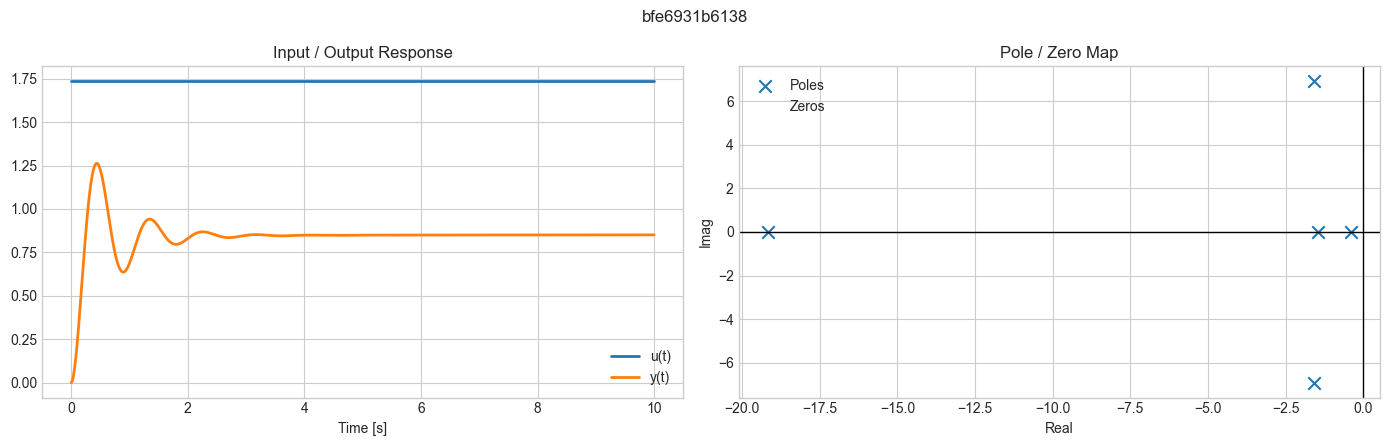

In [3]:
generated = generate_sample(DatasetConfig(seed=42, count=1), sample_index=0).to_dict()
summarize_sample(generated)
plot_sample(generated)

## Load a sample from exported JSONL

If you already exported samples with `python3 -m controlgen.cli --count 100 --output artifacts/samples.jsonl`,
set `JSONL_PATH` below and visualize any row.

In [4]:
JSONL_PATH = ROOT / "artifacts" / "samples.jsonl"
SAMPLE_INDEX = 0

if JSONL_PATH.exists():
    loaded = load_jsonl_sample(JSONL_PATH, index=SAMPLE_INDEX)
    summarize_sample(loaded)
    plot_sample(loaded)
else:
    print(f"No JSONL file found at {JSONL_PATH}")

No JSONL file found at /home/fan/AP/ControlGen/artifacts/samples.jsonl
